In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [61]:


data = pd.read_csv('Telco_customer_churn_cleaned.csv')

In [62]:
data.head()

,Unnamed: 0,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,2,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,3,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,4,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [63]:
data.drop('Unnamed: 0', axis =1, inplace=True)

In [64]:
#split in X and y
X = data.drop('Churn', axis = 1)
y = data['Churn']

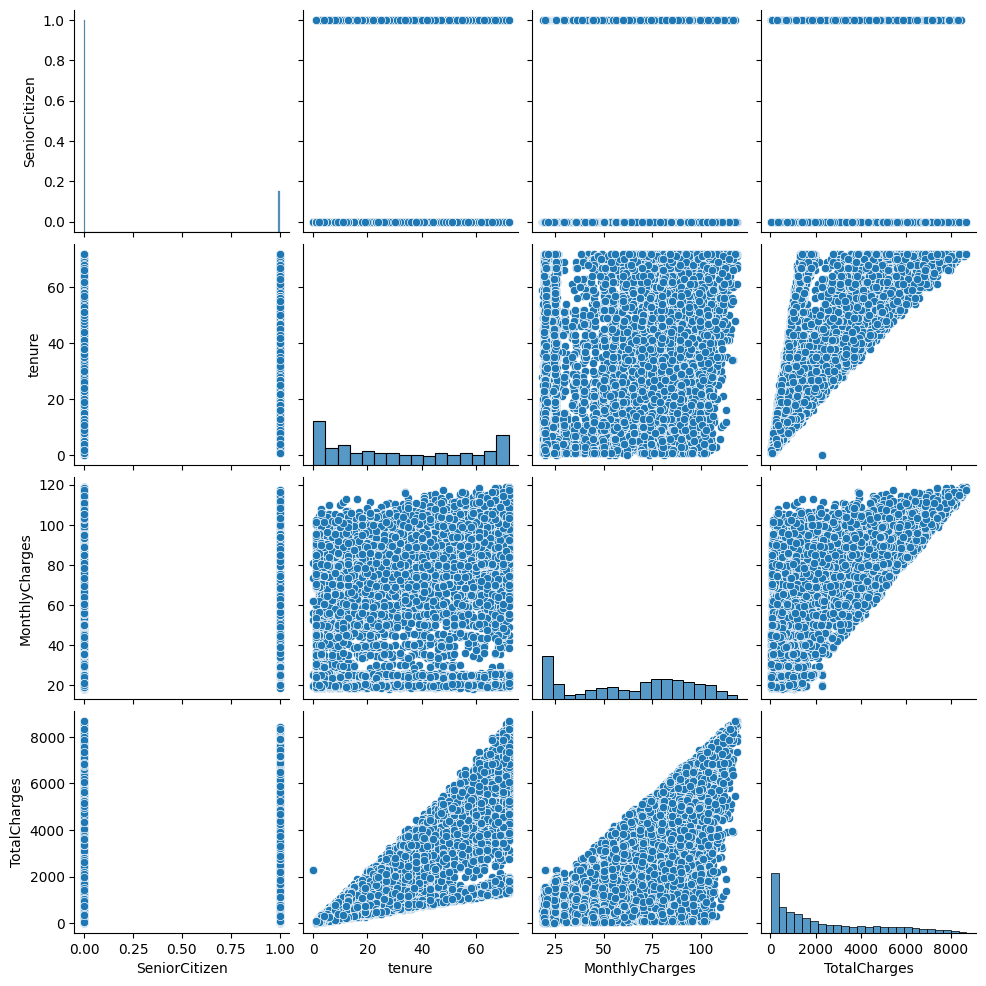

In [65]:
#chekc for multicorrelation
sns.pairplot(X)



In [66]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [67]:
#fixing y column
y = [1 if x == 'Yes' else 0 for x in y]


In [68]:
#onehot encoding and standard scalling on objects
num_featuers = X.select_dtypes(exclude = 'object').columns
obj_features = X.select_dtypes(include= 'object').columns

#initiate transformation

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ohe = OneHotEncoder(drop= 'first')
scaler = StandardScaler()

preprocessor = ColumnTransformer([('OneHotEncoder', ohe, obj_features),
                                  ('StandarScaler', scaler, num_featuers)], remainder= 'passthrough')

In [69]:
#fit and transform data
X_scaled = preprocessor.fit_transform(X)



In [70]:
#feature extraction
from sklearn.decomposition import PCA
pca = PCA(n_components= 2)
X_pca = pca.fit_transform(X_scaled)

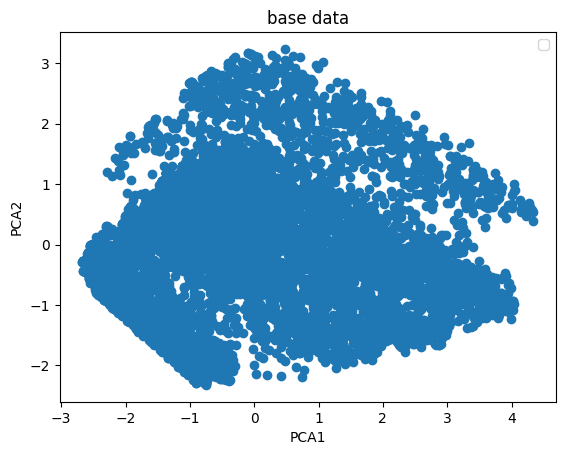

In [71]:
#plot and check for clusters
plt.scatter(X_pca[:,0],
            X_pca[:,1])

plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('base data')
plt.legend()
plt.show()

KNN clustering

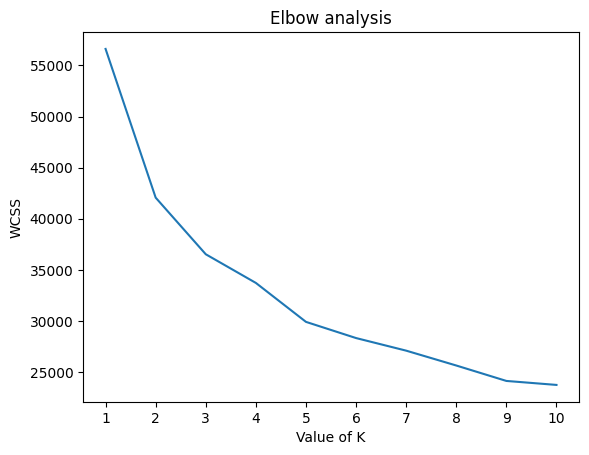

In [72]:
#determine value of K with elbow method

from sklearn.cluster import KMeans

WCSS = []

for k in range(1,11):
    kmeans = KMeans(n_clusters= k, init= 'k-means++')
    kmeans.fit(X_scaled)
    WCSS.append(kmeans.inertia_)

#plot elbow

plt.plot(range(1,11),
         WCSS)
plt.xticks(range(1,11))
plt.xlabel('Value of K')
plt.ylabel('WCSS')
plt.title('Elbow analysis')
plt.show()

as per knee locator, the optimal value of K is 5


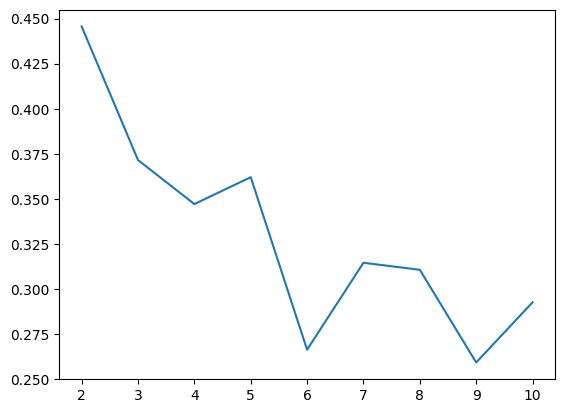

In [73]:
#using other methods to determine K value

#1. Knee locator

from kneed import KneeLocator

kl = KneeLocator(range(1,11), WCSS, curve = 'convex', direction= 'decreasing')
print('as per knee locator, the optimal value of K is', kl.elbow)

#2. shiloutte mtheod
from sklearn.metrics import silhouette_score

sil_coeff = []

for k in range(2,11):
    kmeans = KMeans(n_clusters= k, init= 'k-means++')
    kmeans.fit(X_scaled)
    score = silhouette_score(X_pca, kmeans.labels_)
    sil_coeff.append(score)

plt.plot(range(2,11), sil_coeff)

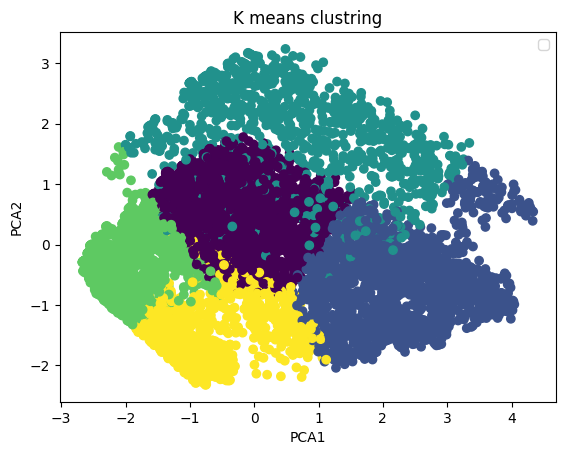

In [74]:
#clustring with k = 7
kmeans = KMeans(n_clusters= 5, init= 'k-means++')
kmeans.fit(X_scaled)

plt.scatter(X_pca[:,0],
            X_pca[:,1],
            c = kmeans.labels_)

plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('K means clustring')
plt.legend()
plt.show()

Agglomerative Clustering

{'icoord': [[5.0, 5.0, 15.0, 15.0],
  [35.0, 35.0, 45.0, 45.0],
  [25.0, 25.0, 40.0, 40.0],
  [55.0, 55.0, 65.0, 65.0],
  [85.0, 85.0, 95.0, 95.0],
  [75.0, 75.0, 90.0, 90.0],
  [60.0, 60.0, 82.5, 82.5],
  [32.5, 32.5, 71.25, 71.25],
  [10.0, 10.0, 51.875, 51.875],
  [105.0, 105.0, 115.0, 115.0],
  [125.0, 125.0, 135.0, 135.0],
  [110.0, 110.0, 130.0, 130.0],
  [155.0, 155.0, 165.0, 165.0],
  [145.0, 145.0, 160.0, 160.0],
  [195.0, 195.0, 205.0, 205.0],
  [185.0, 185.0, 200.0, 200.0],
  [175.0, 175.0, 192.5, 192.5],
  [152.5, 152.5, 183.75, 183.75],
  [120.0, 120.0, 168.125, 168.125],
  [30.9375, 30.9375, 144.0625, 144.0625],
  [215.0, 215.0, 225.0, 225.0],
  [245.0, 245.0, 255.0, 255.0],
  [235.0, 235.0, 250.0, 250.0],
  [265.0, 265.0, 275.0, 275.0],
  [242.5, 242.5, 270.0, 270.0],
  [220.0, 220.0, 256.25, 256.25],
  [285.0, 285.0, 295.0, 295.0],
  [305.0, 305.0, 315.0, 315.0],
  [290.0, 290.0, 310.0, 310.0],
  [238.125, 238.125, 300.0, 300.0],
  [325.0, 325.0, 335.0, 335.0],
  [355.0

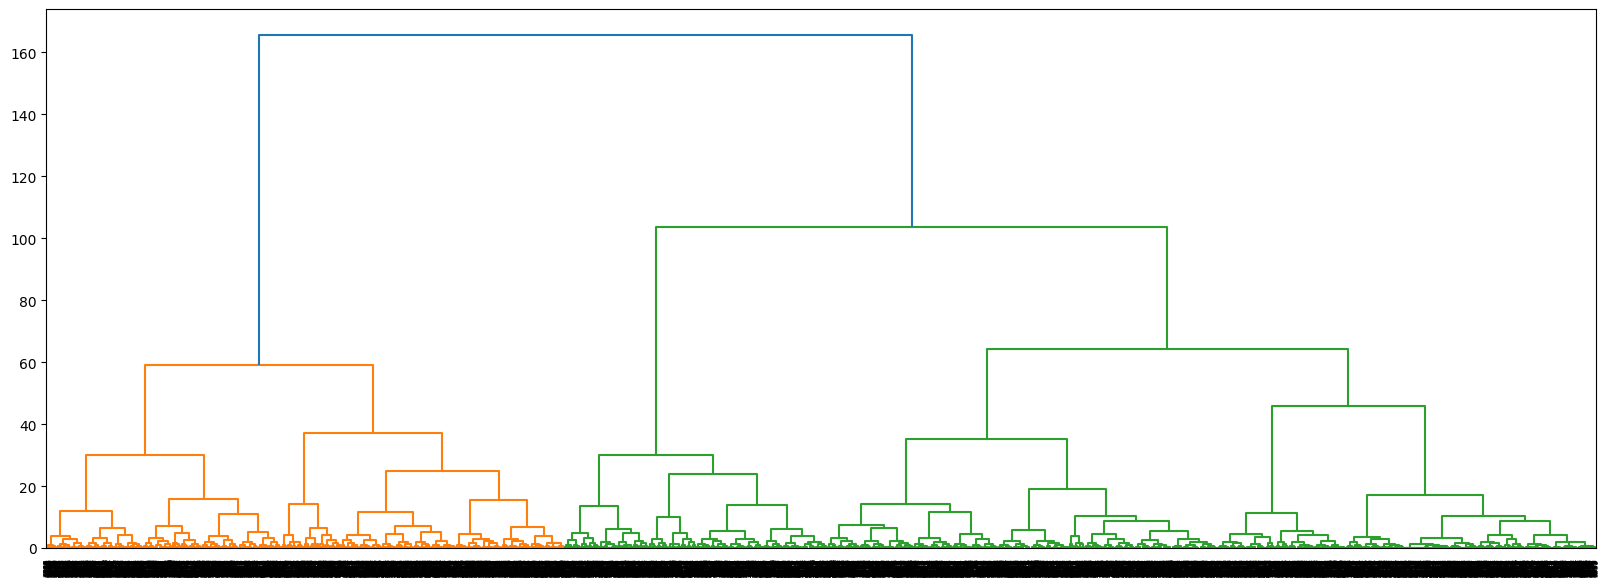

In [75]:
#creating dendrogram

import scipy.cluster.hierarchy as sc
plt.figure(figsize= (20,7))
sc.dendrogram(sc.linkage(X_pca,method= 'ward'))

#number of clusters are 5

In [76]:
#create cluster
from sklearn.cluster import AgglomerativeClustering
h_cluster = AgglomerativeClustering(n_clusters=5,
                                    metric= 'euclidean',
                                    linkage='ward')
h_cluster.fit(X_pca)


,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",5
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


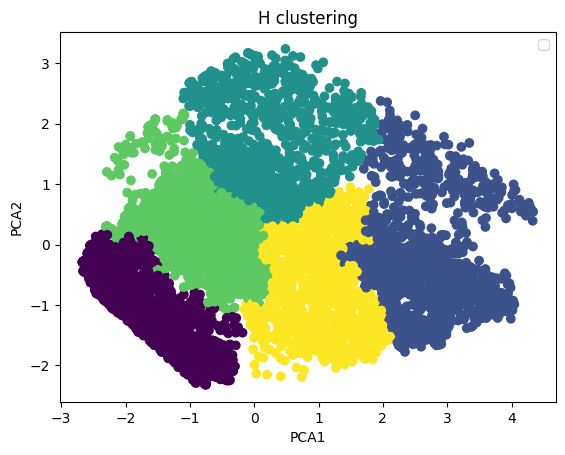

In [77]:
#visualize clusters
plt.scatter(X_pca[:,0],
            X_pca[:,1],
            c = h_cluster.labels_)

plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('H clustering')
plt.legend()
plt.show()

DBSCAN clustring

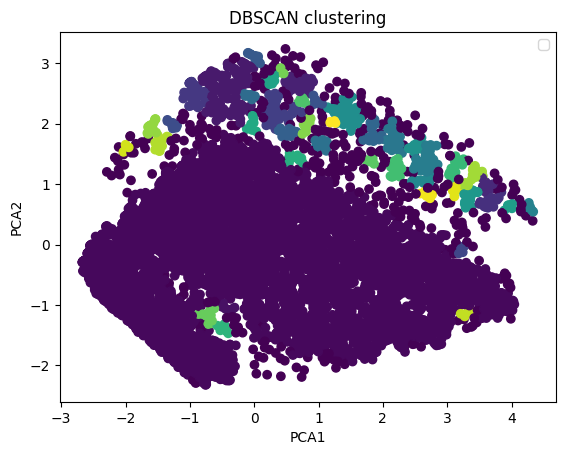

In [78]:
from sklearn.cluster import DBSCAN
db_cluster = DBSCAN(eps= .1)
db_cluster.fit(X_pca)

plt.scatter(X_pca[:,0],
            X_pca[:,1],
            c = db_cluster.labels_)

plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('DBSCAN clustering')
plt.legend()
plt.show()

Adding cluster labels to the base data

In [80]:
X['kmeans_label'] = kmeans.labels_
X['agglo_labels'] = h_cluster.labels_
X['dbcan_labels'] = db_cluster.labels_

In [82]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,kmeans_label,agglo_labels,dbcan_labels
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,3,3,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,3,3,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,3,3,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,4,3,1
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,3,0
